# 03 - Model 1: simple CNN

The baseline, built only from the basic layers of the course: a `Sequential` model with 5 blocks of Conv 3x3 + ReLU + MaxPool 2x2, then Flatten, one Dense layer of 256 units, Dropout 0.5 and a softmax over the 16 classes (8 fruits x fresh/spoiled). The fruit type and the freshness are read from the 16 probabilities in notebook 06.

In [1]:
import os, sys
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
sys.path.insert(0, os.path.abspath(".."))
import tensorflow as tf
tf.get_logger().setLevel("ERROR")

import time
import keras
from keras import layers
import pandas as pd
import matplotlib.pyplot as plt

from src.config import FIGURES_DIR, IMG_SIZE, LOGS_DIR, MODELS_DIR, NUM_COMBINED, REPORTS_DIR, SEED
from src.data_pipeline import load_split, make_dataset
from src.evaluation import compute_metrics, predict
%matplotlib inline

In [2]:
RUN = "model1_simple_cnn"
BATCH_SIZE = 32
EPOCHS = 40  # số epoch tối đa, EarlyStopping có thể dừng sớm hơn
LEARNING_RATE = 1e-3
DROPOUT = 0.5

# True: train lại từ đầu (khoảng 4 giờ trên CPU); False: load model và lịch sử train đã lưu
TRAIN = False

## 1. Data

Labels: one class out of 16 (`combined_label = fruit * 2 + freshness`). The training images are augmented (notebook 02), the validation images are not.

In [3]:
keras.utils.set_random_seed(SEED)
train_ds = make_dataset("train", label_mode="combined", batch_size=BATCH_SIZE, augment=True)
val_ds = make_dataset("val", label_mode="combined", batch_size=BATCH_SIZE)
val_df = load_split("val")
print(f"train: {len(load_split('train'))} images in {len(train_ds)} batches | val: {len(val_df)} images")

train: 10320 images in 323 batches | val: 2203 images


## 2. Model

In [4]:
def build_simple_cnn(dropout=0.5):
    model = keras.Sequential(name="model1_simple_cnn")
    model.add(keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image"))
    model.add(layers.Rescaling(1.0 / 255, name="rescale"))  # chuẩn hoá pixel từ [0, 255] về [0, 1]
    for i, filters in enumerate([32, 64, 128, 128, 256], start=1):
        # Conv 3x3 học đặc trưng cục bộ (cạnh, màu, vết đốm); MaxPooling 2x2 giảm kích thước một nửa
        model.add(layers.Conv2D(filters, 3, padding="same", activation="relu", name=f"conv{i}"))
        model.add(layers.MaxPooling2D(2, name=f"pool{i}"))
    model.add(layers.Flatten(name="flatten"))  # 7 x 7 x 256 -> vector 12544 giá trị
    model.add(layers.Dense(256, activation="relu", name="fc1"))
    model.add(layers.Dropout(dropout, name="dropout"))  # tắt ngẫu nhiên 50% neuron khi train để giảm overfitting
    model.add(layers.Dense(NUM_COMBINED, activation="softmax", name="combined"))  # softmax: xác suất 16 lớp, tổng = 1
    model.compile(
        optimizer=keras.optimizers.Adam(LEARNING_RATE),
        loss="sparse_categorical_crossentropy",  # nhãn là số nguyên (không one-hot)
        metrics=["accuracy"],
    )
    return model


model = build_simple_cnn(DROPOUT)
model.summary()

Model: "model1_simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescale (Rescaling)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool5 (MaxPooling2D)            │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ combined (Dense)                │ (None, 16)             │         4,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,751,632 (14.31 MB)

 Trainable params: 3,751,632 (14.31 MB)

 Non-trainable params: 0 (0.00 B)

The feature map shrinks from 224 x 224 to 7 x 7 while the number of filters grows from 32 to 256. Most parameters (3.2 M of 3.75 M) are in the first Dense layer: Flatten turns the 7 x 7 x 256 feature map into 12,544 values and every one of them is connected to the 256 units. This layer is where the model can overfit.

Loss: sparse categorical cross-entropy (the labels are class numbers, not one-hot vectors), optimizer Adam with learning rate 1e-3.

## 3. Training

- `ModelCheckpoint` saves the epoch with the lowest validation loss,
- `EarlyStopping` stops after 8 epochs without a better validation loss,
- `ReduceLROnPlateau` multiplies the learning rate by 0.3 after 3 epochs without improvement,
- `CSVLogger` writes the loss and accuracy of every epoch to `logs/<run>/history.csv`.

In [5]:
def make_callbacks(run):
    (LOGS_DIR / run).mkdir(parents=True, exist_ok=True)
    MODELS_DIR.mkdir(exist_ok=True)
    return [
        # lưu lại epoch có val_loss thấp nhất
        keras.callbacks.ModelCheckpoint(str(MODELS_DIR / f"{run}.keras"), monitor="val_loss", save_best_only=True),
        # dừng khi val_loss không giảm sau 8 epoch, lấy lại trọng số tốt nhất
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
        # giảm learning rate còn 0.3 lần khi val_loss không giảm sau 3 epoch
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-6, verbose=1),
        keras.callbacks.CSVLogger(str(LOGS_DIR / run / "history.csv")),
    ]


def save_to_log(row):
    path = REPORTS_DIR / "experiment_log.csv"
    log = pd.read_csv(path)
    log = pd.concat([log[log["run"] != row["run"]], pd.DataFrame([row])], ignore_index=True)
    log.to_csv(path, index=False)


if TRAIN:
    t0 = time.time()
    model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=make_callbacks(RUN), verbose=2)
    minutes = (time.time() - t0) / 60

model = keras.models.load_model(MODELS_DIR / f"{RUN}.keras")  # model ở epoch tốt nhất
history = pd.read_csv(LOGS_DIR / RUN / "history.csv")
best = history["val_loss"].idxmin()
print(f"{len(history)} epochs, best epoch {best + 1}: val_loss {history.val_loss[best]:.4f}, val_accuracy {history.val_accuracy[best]:.4f}")
show = history[["loss", "accuracy", "val_loss", "val_accuracy", "learning_rate"]]
show.index = show.index + 1
show.tail(8)

40 epochs, best epoch 40: val_loss 0.0978, val_accuracy 0.9750


,loss,accuracy,val_loss,val_accuracy,learning_rate
33,0.036166,0.988275,0.146049,0.965502,0.000090
34,0.027011,0.990310,0.123748,0.971403,0.000027
35,0.030256,0.990795,0.110345,0.971857,0.000027
36,0.029813,0.988953,0.118325,0.973672,0.000027
37,0.027395,0.990891,0.109874,0.971857,0.000027
38,0.027646,0.990116,0.112980,0.972310,0.000027
39,0.024807,0.992829,0.107415,0.975034,0.000027
40,0.023638,0.992248,0.097821,0.975034,0.000027


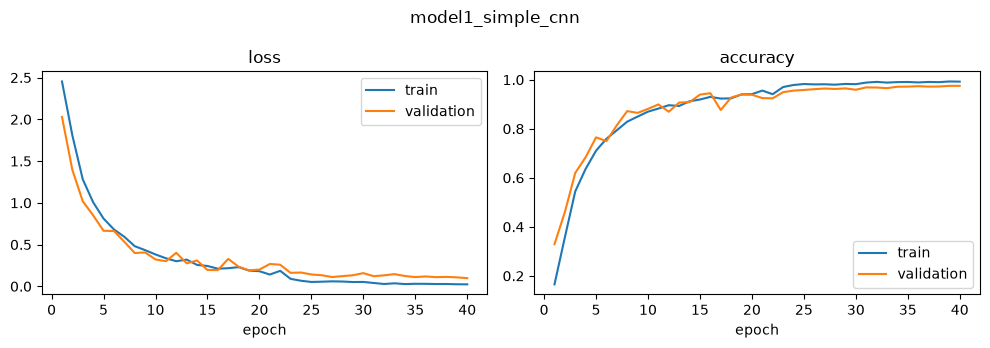

In [6]:
def plot_history(history, title):
    epochs = range(1, len(history) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    for ax, key in zip(axes, ["loss", "accuracy"]):
        ax.plot(epochs, history[key], label="train")
        ax.plot(epochs, history["val_" + key], label="validation")
        ax.set_title(key)
        ax.set_xlabel("epoch")
        ax.legend()
    fig.suptitle(title)
    plt.tight_layout()
    return fig


fig = plot_history(history, RUN)
fig.savefig(FIGURES_DIR / "learning_curves" / f"{RUN}.png", dpi=150, bbox_inches="tight")

The training and validation curves stay close. The validation loss was still going down slowly at epoch 40, so this run ended at the epoch limit and not by early stopping.

## 4. Validation results

The test set is only used in notebook 06.

In [7]:
metrics = compute_metrics(val_df, predict(model, val_ds))
if TRAIN:
    save_to_log({"run": RUN, "model": "simple_cnn", "augmentation": True, "learning_rate": LEARNING_RATE,
                 "max_epochs": EPOCHS, "epochs_trained": len(history), "best_epoch": best + 1,
                 "train_minutes": round(minutes, 1), **{f"val_{k}": round(v, 4) for k, v in metrics.items()},
                 "params": model.count_params()})
pd.Series(metrics).round(4).to_frame("validation")

,validation
fruit_accuracy,0.9814
fruit_precision,0.9821
fruit_recall,0.9818
fruit_f1,0.9818
freshness_accuracy,0.9873
freshness_precision,0.9818
freshness_recall,0.9950
freshness_f1,0.9883
freshness_macro_f1,0.9872
freshness_auc,0.9992


## 5. Ablation: no data augmentation

Same model and settings, but the training images are used as they are.

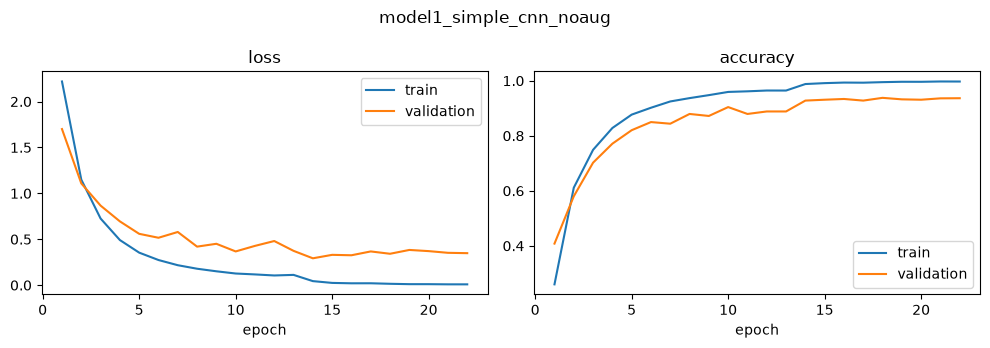

In [8]:
RUN_NOAUG = RUN + "_noaug"
if TRAIN:
    keras.utils.set_random_seed(SEED)
    train_plain = make_dataset("train", label_mode="combined", batch_size=BATCH_SIZE, augment=False)
    model_noaug = build_simple_cnn(DROPOUT)
    t0 = time.time()
    model_noaug.fit(train_plain, validation_data=val_ds, epochs=EPOCHS, callbacks=make_callbacks(RUN_NOAUG), verbose=2)
    minutes = (time.time() - t0) / 60

model_noaug = keras.models.load_model(MODELS_DIR / f"{RUN_NOAUG}.keras")
history_noaug = pd.read_csv(LOGS_DIR / RUN_NOAUG / "history.csv")
metrics_noaug = compute_metrics(val_df, predict(model_noaug, val_ds))
if TRAIN:
    save_to_log({"run": RUN_NOAUG, "model": "simple_cnn", "augmentation": False, "learning_rate": LEARNING_RATE,
                 "max_epochs": EPOCHS, "epochs_trained": len(history_noaug),
                 "best_epoch": int(history_noaug["val_loss"].idxmin()) + 1, "train_minutes": round(minutes, 1),
                 **{f"val_{k}": round(v, 4) for k, v in metrics_noaug.items()}, "params": model_noaug.count_params()})
fig = plot_history(history_noaug, RUN_NOAUG)
fig.savefig(FIGURES_DIR / "learning_curves" / f"{RUN_NOAUG}.png", dpi=150, bbox_inches="tight")

In [9]:
def summary(history, metrics):
    best = history.loc[history["val_loss"].idxmin()]
    return {"epochs trained": len(history), "best epoch": int(history["val_loss"].idxmin()) + 1,
            "train accuracy (last epoch)": history["accuracy"].iloc[-1], "train loss (best epoch)": best["loss"],
            "val loss (best epoch)": best["val_loss"], "val joint accuracy": metrics["joint_accuracy"],
            "val freshness F1": metrics["freshness_f1"]}


pd.DataFrame({"with augmentation": summary(history, metrics),
              "without augmentation": summary(history_noaug, metrics_noaug)}).round(4)

,with augmentation,without augmentation
epochs trained,40.0000,22.0000
best epoch,40.0000,14.0000
train accuracy (last epoch),0.9922,0.9971
train loss (best epoch),0.0236,0.0440
val loss (best epoch),0.0978,0.2926
val joint accuracy,0.9750,0.9278
val freshness F1,0.9883,0.9572


Without augmentation the training accuracy goes to almost 100 %, but the validation loss stops improving after epoch 14 and then rises again, and the validation accuracy stays around 93 %: the model memorises the training images (overfitting). With augmentation the model sees a slightly different version of every image in each epoch, which works as regularisation. Both runs are compared on the test set in notebook 06.